In [5]:
import numpy as np
import matplotlib.pyplot as plt
from kneed import KneeLocator

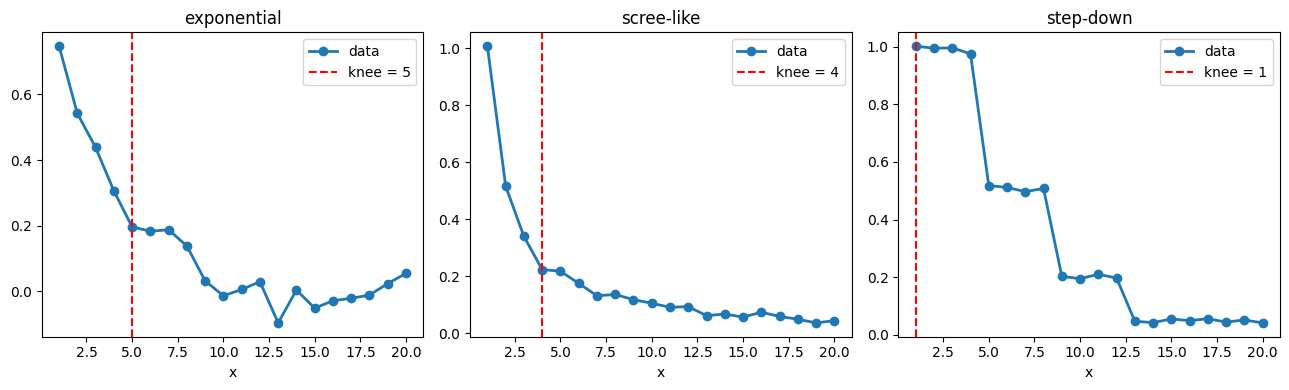

In [6]:
# --- synthetic decreasing curves ---
x = np.arange(1, 21)

curves = {
    "exponential":  np.exp(-0.3 * x) + 0.05 * np.random.default_rng(0).standard_normal(len(x)),
    "scree-like":   1.0 / x + 0.02 * np.random.default_rng(1).standard_normal(len(x)),
    "step-down":    np.array([1.0]*4 + [0.5]*4 + [0.2]*4 + [0.05]*8)
                    + 0.01 * np.random.default_rng(2).standard_normal(20),
}

fig, axes = plt.subplots(1, 3, figsize=(13, 4))

for ax, (name, y) in zip(axes, curves.items()):
    knl = KneeLocator(x, y, curve="convex", direction="decreasing", S=1.0)
    knee = knl.knee

    ax.plot(x, y, "o-", lw=2, label="data")
    if knee is not None:
        ax.axvline(knee, color="red", ls="--", lw=1.5, label=f"knee = {knee}")
    ax.set_title(name)
    ax.set_xlabel("x")
    ax.legend()

plt.tight_layout()
plt.show()

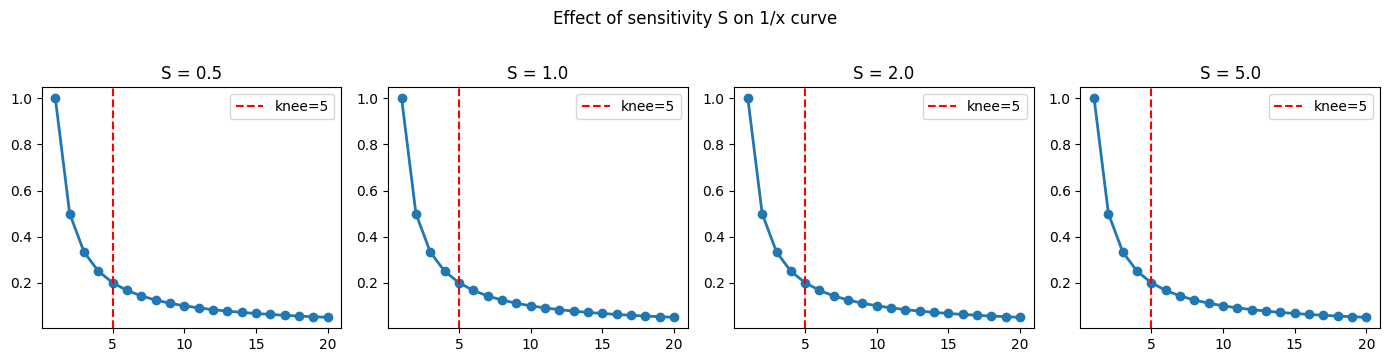

In [7]:
# sensitivity parameter S: higher S → later knee
x = np.arange(1, 21)
y = 1.0 / x

fig, axes = plt.subplots(1, 4, figsize=(14, 3.5))
for ax, S in zip(axes, [0.5, 1.0, 2.0, 5.0]):
    knl = KneeLocator(x, y, curve="convex", direction="decreasing", S=S)
    knee = knl.knee
    ax.plot(x, y, "o-", lw=2)
    if knee is not None:
        ax.axvline(knee, color="red", ls="--", lw=1.5, label=f"knee={knee}")
    ax.set_title(f"S = {S}")
    ax.legend()

plt.suptitle("Effect of sensitivity S on 1/x curve", y=1.02)
plt.tight_layout()
plt.show()